In [1]:
!pip install pandas numpy matplotlib seaborn plotly

In [2]:
from google.colab import files
uploaded = files.upload()

Saving churn_labels.csv to churn_labels.csv
Saving customers.csv to customers.csv
Saving intervention_history.csv to intervention_history.csv
Saving orders.csv to orders.csv
Saving support_tickets.csv to support_tickets.csv
Saving web_events_snapshot.csv to web_events_snapshot.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
support = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")
campaign = pd.read_csv("intervention_history.csv")
labels = pd.read_csv("churn_labels.csv")

In [5]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

snapshot = pd.Timestamp(
    "2025-09-30"
)

orders = orders[
    orders["order_date"] <= snapshot
]

In [6]:
last_purchase = (
    orders
    .groupby("customer_id")
    ["order_date"]
    .max()
)

recency = (
    snapshot - last_purchase
).dt.days

In [7]:
frequency = (
    orders
    .groupby("customer_id")
    ["order_id"]
    .count()
)

In [8]:
monetary = (
    orders
    .groupby("customer_id")
    ["gross_amount"]
    .sum()
)

In [9]:
rfm = pd.DataFrame({
    "recency": recency,
    "frequency": frequency,
    "monetary": monetary
}).reset_index()

In [10]:
rfm["R"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

In [11]:
rfm["F"] = pd.qcut(
    rfm["frequency"].rank(
        method="first"
    ),
    5,
    labels=[1,2,3,4,5]
)

In [12]:
rfm["M"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [13]:
tickets = (
    support
    .groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

In [14]:
returns = (
    orders
    .groupby("customer_id")
    ["returned"]
    .mean()
    .reset_index(
        name="return_rate"
    )
)

In [15]:
campaign_signal = campaign[
[
    "customer_id",
    "last_campaign_received",
    "manual_priority_bucket"
]
]

In [16]:
web_signal = web[
[
    "customer_id",
    "sessions_30d",
    "campaign_clicks_30d"
]
]

In [17]:
segment_df = (
    rfm
    .merge(tickets,
           how="left")
    .merge(returns,
           how="left")
    .merge(web_signal,
           how="left")
    .merge(campaign_signal,
           how="left")
    .merge(labels,
           how="left")
)

In [30]:
for col in segment_df.columns:
    if isinstance(segment_df[col].dtype, pd.CategoricalDtype):
        segment_df[col] = segment_df[col].astype('object')

segment_df.fillna(
    0,
    inplace=True
)

In [20]:
def assign_segment(row):

    if (
        row["R"] >= 4 and
        row["F"] >= 4 and
        row["M"] >= 4
    ):
        return "Champions"

    elif (
        row["F"] >= 4
    ):
        return "Loyal"

    elif (
        row["monetary"] >
        segment_df["monetary"].quantile(.75)
        and row["ticket_count"] > 2
    ):
        return "High Value Unhappy"

    elif (
        row["recency"] > 90
    ):
        return "At Risk"

    elif (
        row["return_rate"] > .40
    ):
        return "Discount Sensitive"

    else:
        return "Dormant"

In [21]:
segment_df["segment_name"] = (
    segment_df.apply(
        assign_segment,
        axis=1
    )
)

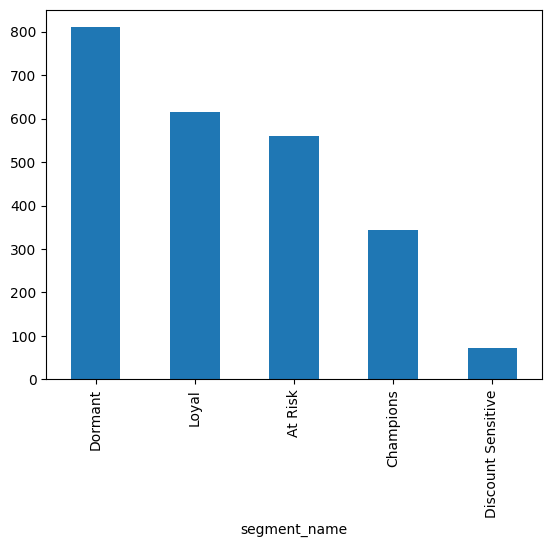

In [22]:
segment_df[
    "segment_name"
].value_counts().plot(
    kind="bar"
)

plt.show()

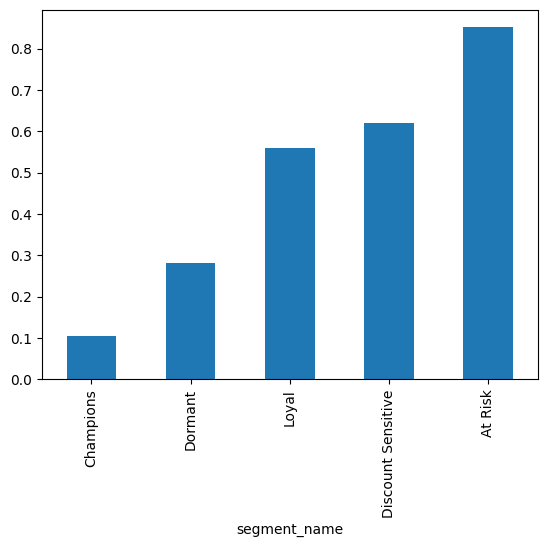

In [23]:
segment_churn = (
    segment_df
    .groupby("segment_name")
    ["churn_next_60d"]
    .mean()
    .sort_values()
)

segment_churn.plot(
    kind="bar"
)

plt.show()

In [24]:
summary = (
    segment_df
    .groupby("segment_name")
    .agg({

        "recency":"mean",

        "frequency":"mean",

        "monetary":"mean",

        "ticket_count":"mean",

        "return_rate":"mean",

        "churn_next_60d":"mean"

    })
)

In [25]:
segment_df.to_csv(
    "segments.csv",
    index=False
)

In [26]:
segment_df.groupby(
    "segment_name"
)["churn_next_60d"].mean()

,churn_next_60d
segment_name,
At Risk,0.851521
Champions,0.104651
Discount Sensitive,0.619718
Dormant,0.280247
Loyal,0.558442


In [27]:
segment_df.groupby(
    "manual_priority_bucket"
)["churn_next_60d"].mean()

,churn_next_60d
manual_priority_bucket,
high,0.747206
low,0.100410
medium,0.279039


In [28]:
segment_summary = (
    segment_df
    .groupby("segment_name")
    .agg({

        "recency":"mean",

        "frequency":"mean",

        "monetary":"mean",

        "ticket_count":"mean",

        "return_rate":"mean",

        "churn_next_60d":"mean"

    })
)

segment_summary

,recency,frequency,monetary,ticket_count,return_rate,churn_next_60d
segment_name,,,,,,
At Risk,176.248658,1.824687,1377.749070,0.427549,0.053369,0.851521
Champions,20.654070,6.375000,4920.766366,1.456395,0.066165,0.104651
Discount Sensitive,38.802817,1.521127,1215.843944,1.197183,0.805164,0.619718
Dormant,37.183951,1.772840,1320.552062,0.380247,0.016152,0.280247
Loyal,115.584416,5.487013,4058.922565,1.279221,0.064666,0.558442


In [31]:
import os

output_dir = "outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

segment_summary.to_csv(
    os.path.join(output_dir, "segment_summary.csv")
)

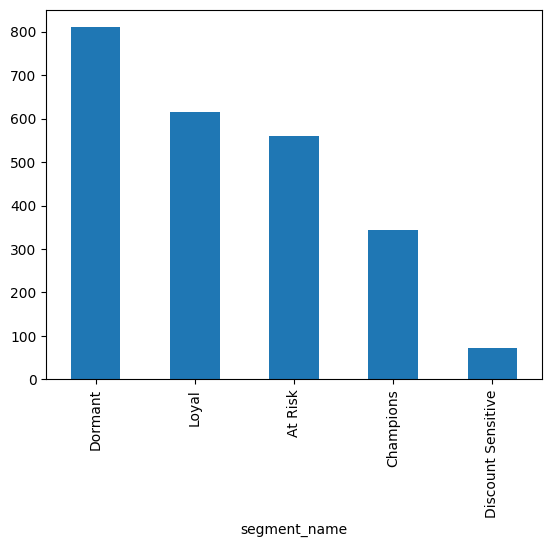

In [32]:
segment_df[
    "segment_name"
].value_counts().plot(
    kind="bar"
)

plt.savefig(
    "outputs/segment_distribution.png"
)

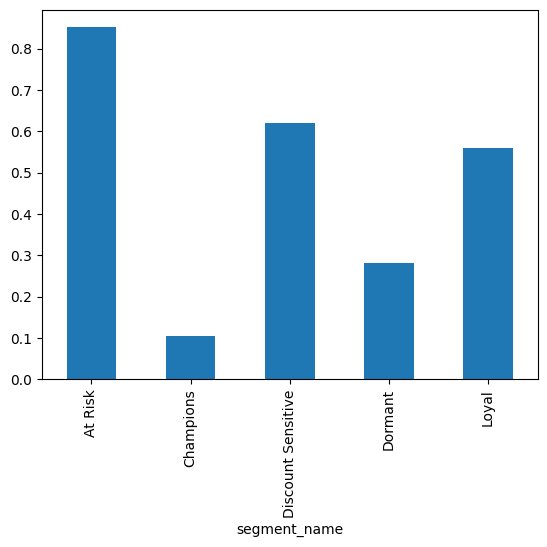

In [33]:
segment_churn = (
    segment_df
    .groupby("segment_name")
    ["churn_next_60d"]
    .mean()
)

segment_churn.plot(
    kind="bar"
)

plt.savefig(
    "outputs/segment_churn_rate.png"
)

In [34]:
manual_review = (

    segment_df

    .sort_values(
        "churn_next_60d",
        ascending=False
    )

    .head(10)

)

manual_review[
[
    "customer_id",

    "segment_name",

    "recency",

    "frequency",

    "monetary",

    "ticket_count"

]]

,customer_id,segment_name,recency,frequency,monetary,ticket_count
2382,CUST02383,Loyal,108,4,1842.06,2.0
2379,CUST02380,At Risk,136,1,331.92,0.0
2378,CUST02379,At Risk,112,1,588.32,0.0
30,CUST00031,Dormant,49,1,672.95,0.0
24,CUST00025,Loyal,165,7,4868.86,3.0
20,CUST00021,Dormant,77,2,1059.30,1.0
19,CUST00020,At Risk,368,3,4487.95,1.0
17,CUST00018,At Risk,111,1,329.21,0.0
16,CUST00017,At Risk,286,3,1699.14,0.0
2367,CUST02368,Loyal,157,4,4203.85,3.0


In [35]:
manual_review.to_csv(
    "manual_review_cases.csv",
    index=False
)

In [36]:
import os

os.listdir('/content/outputs')

['segment_churn_rate.png', 'segment_distribution.png', 'segment_summary.csv']

In [37]:
plt.savefig(
    "outputs/churn_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>